# Alocação de horários universitários: heurística gulosa vs. VNS

Notebook do TCC *Heurística gulosa e Busca em Vizinhança Variável na alocação de horários universitários: um estudo em instâncias sintéticas*.

Cada turma é um vértice; uma aresta liga duas turmas que compartilham professor ou grupo de alunos; cada cor é um horário. O notebook compara:

- **Guloso por grau**: ordena as turmas por grau decrescente e atribui a menor cor livre entre os vizinhos já coloridos.
- **VNS (Busca em Vizinhança Variável)**: parte de uma atribuição aleatória com o mesmo número de cores do guloso e alterna perturbações de `k` turmas com busca local.

**Execução única.** Todos os resultados do trabalho saem de uma única execução deste notebook, do início ao fim (*Kernel → Restart & Run All*). Os arquivos gerados ficam na pasta `resultados/`:

| Arquivo | Conteúdo | Uso no TCC |
|---|---|---|
| `instancias.csv` | Características dos grafos | Tabela 2 |
| `exemplo_120.csv` | Exemplo ilustrativo de 120 turmas | Seção 5.2 |
| `guloso_tempos.csv` | Tempo do guloso (mediana de `timeit`) | Tabela 3 |
| `rodadas_vns.csv` | Cada rodada da VNS: tempo total, tempo até a primeira solução viável, conflitos, horários, movimentos da busca local | Tabelas 3 e 4 |
| `resumo_benchmark.csv` | Medianas por tamanho e razão de tempos | Tabela 3, Figura 1 |
| `teste_folga_cores.csv` | VNS com K e K + 1 cores | Seção 5.5 |
| `figura_benchmark.png` | Tempo (escala log.) e conflitos | Figura 1 |
| `ambiente.json` | Versões e hardware | Seção 4.4 |

## 0. Configuração

In [ ]:
import json
import os
import platform
import subprocess
import time
import timeit
from datetime import datetime

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Parâmetros do experimento (Capítulo 4 do TCC)
SEMENTE_BASE = 42
TAMANHOS = (60, 100, 140)          # turmas no benchmark
RODADAS_VNS = 3                    # rodadas da VNS por tamanho
ITERACOES_BENCHMARK = 45
KMAX_BENCHMARK = 4
ITERACOES_EXEMPLO = 100            # exemplo ilustrativo de 120 turmas
KMAX_EXEMPLO = 5
MAX_PASSOS_BUSCA_LOCAL = 120
SEMENTES_FOLGA = 23                # rodadas por tamanho no teste K vs. K + 1 (r = 0..22)
TIMEIT_SERIES, TIMEIT_CHAMADAS = 7, 200

PASTA = 'resultados'
os.makedirs(PASTA, exist_ok=True)
INICIO_EXECUCAO = datetime.now().isoformat(timespec='seconds')
print('Início da execução:', INICIO_EXECUCAO)

Início da execução: 2026-10-08T20:38:03


## 1. Instâncias sintéticas

Cada turma recebe um professor e de 1 a 3 grupos de alunos. Duas turmas são adjacentes se compartilham professor ou ao menos um grupo. A geração usa `numpy.random.default_rng(seed)`, então a mesma semente produz a mesma instância.

In [ ]:
def gerar_instancia(n_turmas=120, n_professores=36, n_grupos=56, seed=42):
    gerador = np.random.default_rng(seed)
    turmas = pd.DataFrame({
        'turma': [f'T{indice:03d}' for indice in range(n_turmas)],
        'professor': gerador.integers(0, n_professores, size=n_turmas),
    })
    turmas['grupos'] = [
        tuple(sorted(gerador.choice(n_grupos, size=gerador.integers(1, 4), replace=False)))
        for _ in range(n_turmas)
    ]

    adjacencias = [set() for _ in range(n_turmas)]
    for i in range(n_turmas):
        for j in range(i + 1, n_turmas):
            mesmo_professor = turmas.loc[i, 'professor'] == turmas.loc[j, 'professor']
            grupos_em_comum = set(turmas.loc[i, 'grupos']) & set(turmas.loc[j, 'grupos'])
            if mesmo_professor or grupos_em_comum:
                adjacencias[i].add(j)
                adjacencias[j].add(i)
    return turmas, adjacencias


def parametros_benchmark(n_turmas):
    """Professores e grupos usados no benchmark (seção 4.1)."""
    return dict(n_turmas=n_turmas,
                n_professores=max(6, round(n_turmas * 0.30)),
                n_grupos=max(10, round(n_turmas * 0.47)),
                seed=SEMENTE_BASE + n_turmas)


def caracterizar(turmas, adjacencias, rotulo):
    """Medidas da Tabela 2. O maior grupo (ou professor) forma um clique: é um limite inferior de horários."""
    n = len(adjacencias)
    arestas = sum(map(len, adjacencias)) // 2
    graus = [len(a) for a in adjacencias]
    maior_grupo = pd.Series([g for gs in turmas['grupos'] for g in gs]).value_counts().max()
    maior_professor = turmas['professor'].value_counts().max()
    return {'instancia': rotulo, 'turmas': n, 'arestas': arestas,
            'grau_medio': round(2 * arestas / n, 1), 'grau_maximo': max(graus),
            'densidade': round(2 * arestas / (n * (n - 1)), 3),
            'maior_grupo': int(maior_grupo), 'maior_professor': int(maior_professor),
            'limite_inferior': int(max(maior_grupo, maior_professor))}

## 2. Heurística gulosa por grau

In [ ]:
def coloracao_gulosa(adjacencias):
    n = len(adjacencias)
    ordem = sorted(range(n), key=lambda v: len(adjacencias[v]), reverse=True)
    cores = np.full(n, -1, dtype=int)

    for vertice in ordem:
        cores_vizinhas = {cores[vizinho] for vizinho in adjacencias[vertice] if cores[vizinho] >= 0}
        cor = 0
        while cor in cores_vizinhas:
            cor += 1
        cores[vertice] = cor
    return cores


def contar_conflitos(cores, adjacencias):
    """C(c): arestas cujos extremos têm a mesma cor (cada aresta contada uma vez)."""
    return int(sum(
        cores[u] == cores[v]
        for u in range(len(adjacencias))
        for v in adjacencias[u] if v > u
    ))


def horarios_usados(cores):
    """K(c): quantidade de cores distintas na solução."""
    return int(len(np.unique(cores)))

## 3. Busca em Vizinhança Variável (VNS)

- **Custo**: `F(c) = (n + 1)·C(c) + K(c)` (Equação 3); qualquer conflito pesa mais que um horário.
- **Busca local**: examina trocar a cor de cada turma por cada outra cor e aplica o movimento com maior redução estrita de conflitos, até 120 movimentos.
- **Perturbação**: sorteia novas cores para `k` turmas; `k` volta a 1 após melhora e cresce até `k_max` sem melhora.

Os parâmetros opcionais `registro` e `marcos` só observam a execução: o primeiro conta os movimentos de cada busca local e o segundo guarda, após cada iteração, o tempo decorrido e o melhor custo. Nenhum dos dois altera o uso do gerador aleatório nem as soluções.

In [ ]:
def custo_solucao(individuo, adjacencias):
    conflitos = contar_conflitos(individuo, adjacencias)
    horarios = len(np.unique(individuo))
    return conflitos * (len(individuo) + 1) + horarios


def delta_conflitos(cores, turma, nova_cor, adjacencias):
    cor_atual = cores[turma]
    antes = sum(cores[vizinho] == cor_atual for vizinho in adjacencias[turma])
    depois = sum(cores[vizinho] == nova_cor for vizinho in adjacencias[turma])
    return depois - antes


def busca_local(solucao, adjacencias, n_horarios, gerador, max_passos=MAX_PASSOS_BUSCA_LOCAL, registro=None):
    atual = solucao.copy()
    movimentos = 0
    for _ in range(max_passos):
        melhor_movimento, melhor_delta = None, 0
        for turma in gerador.permutation(len(atual)):
            cor_original = atual[turma]
            for cor in range(n_horarios):
                if cor == cor_original:
                    continue
                delta = delta_conflitos(atual, turma, cor, adjacencias)
                if delta < melhor_delta:
                    melhor_movimento, melhor_delta = (turma, cor), delta
        if melhor_movimento is None:
            break
        atual[melhor_movimento[0]] = melhor_movimento[1]
        movimentos += 1
    if registro is not None:
        registro.append({'movimentos': movimentos, 'conflitos': contar_conflitos(atual, adjacencias)})
    return atual


def executar_vns(adjacencias, n_horarios, seed=SEMENTE_BASE, iteracoes=100, k_max=5, registro=None, marcos=None):
    """VNS básica. `registro` conta movimentos da busca local; `marcos` guarda
    (iteração, segundos desde o início, melhor custo) após cada iteração.
    Nenhum dos dois altera o uso do gerador aleatório nem as soluções."""
    inicio = time.perf_counter()
    gerador = np.random.default_rng(seed)
    melhor = gerador.integers(0, n_horarios, size=len(adjacencias))
    melhor = busca_local(melhor, adjacencias, n_horarios, gerador, registro=registro)
    historico = [custo_solucao(melhor, adjacencias)]
    if marcos is not None:
        marcos.append((0, time.perf_counter() - inicio, historico[-1]))
    k = 1

    for iteracao in range(1, iteracoes + 1):
        candidato = melhor.copy()
        turmas_perturbadas = gerador.choice(len(candidato), size=min(k, len(candidato)), replace=False)
        candidato[turmas_perturbadas] = gerador.integers(0, n_horarios, size=len(turmas_perturbadas))
        candidato = busca_local(candidato, adjacencias, n_horarios, gerador, registro=registro)
        if custo_solucao(candidato, adjacencias) < custo_solucao(melhor, adjacencias):
            melhor, k = candidato, 1
        else:
            k = 1 if k == k_max else k + 1
        historico.append(custo_solucao(melhor, adjacencias))
        if marcos is not None:
            marcos.append((iteracao, time.perf_counter() - inicio, historico[-1]))
    return melhor, historico

## 4. Medição de tempo

- **Guloso**: a chamada dura décimos de milissegundo, então uma medição única é ruidosa. Usa-se a mediana de 7 séries de 200 chamadas (`timeit`).
- **VNS**: cada rodada dura cerca de um segundo e é medida individualmente com `time.perf_counter()`.
- **Tempo até a viabilidade**: a VNS não tem parada antecipada e sempre executa todas as iterações. Por isso, registra-se também o tempo até a primeira solução sem conflitos e até a melhor solução final.

Em ambos os casos, o intervalo cobre só a chamada do algoritmo; geração do grafo e cálculo das métricas ficam fora.

In [ ]:
def medir_guloso(adjacencias):
    series = timeit.repeat(lambda: coloracao_gulosa(adjacencias), number=TIMEIT_CHAMADAS, repeat=TIMEIT_SERIES)
    por_chamada = np.array(series) / TIMEIT_CHAMADAS
    return {'tempo_s': float(np.median(por_chamada)),
            'tempo_min_s': float(por_chamada.min()), 'tempo_max_s': float(por_chamada.max())}


def rodar_vns(adjacencias, n_horarios, seed, iteracoes, k_max):
    registro, marcos = [], []
    inicio = time.perf_counter()
    solucao, historico = executar_vns(adjacencias, n_horarios, seed=seed, iteracoes=iteracoes,
                                      k_max=k_max, registro=registro, marcos=marcos)
    tempo = time.perf_counter() - inicio
    movimentos = [r['movimentos'] for r in registro]

    # Custo F = (n + 1)·C + K: a solução é viável (C = 0) quando F <= n.
    n = len(adjacencias)
    viaveis = [(it, t) for it, t, custo in marcos if custo <= n]
    custo_final = marcos[-1][2]
    it_melhor, t_melhor = next((it, t) for it, t, custo in marcos if custo == custo_final)
    return {'semente': seed, 'tempo_s': tempo,
            'conflitos': contar_conflitos(solucao, adjacencias), 'horarios': horarios_usados(solucao),
            'iteracao_primeira_viavel': viaveis[0][0] if viaveis else np.nan,
            'tempo_ate_viavel_s': viaveis[0][1] if viaveis else np.nan,
            'iteracao_melhor_final': it_melhor, 'tempo_ate_melhor_s': t_melhor,
            'ls_inicial_movimentos': movimentos[0], 'ls_inicial_conflitos': registro[0]['conflitos'],
            'ls_max_movimentos': max(movimentos),
            'ls_chamadas_no_teto': sum(m >= MAX_PASSOS_BUSCA_LOCAL for m in movimentos),
            'ls_chamadas': len(movimentos)}, historico

## 5. Instâncias avaliadas (Tabela 2)

In [ ]:
instancias = {'Exemplo ilustrativo': gerar_instancia(seed=SEMENTE_BASE)}
for n in TAMANHOS:
    instancias[f'Benchmark {n}'] = gerar_instancia(**parametros_benchmark(n))

tabela_instancias = pd.DataFrame([caracterizar(t, a, rotulo) for rotulo, (t, a) in instancias.items()])
tabela_instancias.to_csv(f'{PASTA}/instancias.csv', index=False)
tabela_instancias

,instancia,turmas,arestas,grau_medio,grau_maximo,densidade,maior_grupo,maior_professor,limite_inferior
0,Exemplo ilustrativo,120,683,11.4,25,0.096,10,10,10
1,Benchmark 60,60,349,11.6,21,0.197,9,7,9
2,Benchmark 100,100,554,11.1,21,0.112,8,7,8
3,Benchmark 140,140,866,12.4,23,0.089,9,7,9


## 6. Exemplo ilustrativo com 120 turmas (seção 5.2)

Instância padrão (`seed=42`); VNS com 100 iterações e `k_max = 5`.

In [ ]:
_, grafo_exemplo = instancias['Exemplo ilustrativo']
guloso_exemplo = coloracao_gulosa(grafo_exemplo)
k_exemplo = horarios_usados(guloso_exemplo)
tempo_guloso_exemplo = medir_guloso(grafo_exemplo)
rodada_exemplo, historico_exemplo = rodar_vns(grafo_exemplo, k_exemplo, SEMENTE_BASE,
                                              ITERACOES_EXEMPLO, KMAX_EXEMPLO)

exemplo = pd.DataFrame([
    {'algoritmo': 'Guloso', 'conflitos': contar_conflitos(guloso_exemplo, grafo_exemplo),
     'horarios': k_exemplo, **tempo_guloso_exemplo},
    {'algoritmo': 'VNS', **rodada_exemplo},
])
exemplo['razao_vns_guloso'] = rodada_exemplo['tempo_s'] / tempo_guloso_exemplo['tempo_s']
exemplo.to_csv(f'{PASTA}/exemplo_120.csv', index=False)
print('Custo da VNS: inicial', historico_exemplo[0], '| final', historico_exemplo[-1],
      '| constante:', len(set(historico_exemplo)) == 1)
exemplo

Custo da VNS: inicial 10 | final 10 | constante: True


,algoritmo,conflitos,horarios,tempo_s,tempo_min_s,tempo_max_s,semente,iteracao_primeira_viavel,tempo_ate_viavel_s,iteracao_melhor_final,tempo_ate_melhor_s,ls_inicial_movimentos,ls_inicial_conflitos,ls_max_movimentos,ls_chamadas_no_teto,ls_chamadas,razao_vns_guloso
0,Guloso,0,10,0.000238,0.000229,0.000334,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14077.579154
1,VNS,0,10,3.345546,NaN,NaN,42.0,0.0,0.714471,0.0,0.714471,82.0,0.0,82.0,0.0,101.0,14077.579154


## 7. Benchmark (Tabelas 3 e 4)

Uma instância por tamanho; o guloso é medido com `timeit` e a VNS roda três vezes, com sementes `42 + n + r` (r = 0, 1, 2), 45 iterações e `k_max = 4`.

In [ ]:
linhas_guloso, linhas_vns = [], []
for n in TAMANHOS:
    _, grafo = instancias[f'Benchmark {n}']
    guloso = coloracao_gulosa(grafo)
    k_guloso = horarios_usados(guloso)
    linhas_guloso.append({'turmas': n, 'conflitos': contar_conflitos(guloso, grafo),
                          'horarios': k_guloso, **medir_guloso(grafo)})
    for r in range(RODADAS_VNS):
        rodada, _ = rodar_vns(grafo, k_guloso, SEMENTE_BASE + n + r, ITERACOES_BENCHMARK, KMAX_BENCHMARK)
        linhas_vns.append({'turmas': n, 'rodada': r, **rodada})

guloso_tempos = pd.DataFrame(linhas_guloso)
rodadas_vns = pd.DataFrame(linhas_vns)
rodadas_vns['viavel'] = rodadas_vns['conflitos'] == 0
guloso_tempos.to_csv(f'{PASTA}/guloso_tempos.csv', index=False)
rodadas_vns.to_csv(f'{PASTA}/rodadas_vns.csv', index=False)
rodadas_vns

,turmas,rodada,semente,tempo_s,conflitos,horarios,iteracao_primeira_viavel,tempo_ate_viavel_s,iteracao_melhor_final,tempo_ate_melhor_s,ls_inicial_movimentos,ls_inicial_conflitos,ls_max_movimentos,ls_chamadas_no_teto,ls_chamadas,viavel
0,60,0,102,0.713237,0,9,8.0,0.265742,8,0.265742,41,2,41,0,46,True
1,60,1,103,0.622795,0,9,29.0,0.432848,29,0.432848,24,1,24,0,46,True
2,60,2,104,0.659296,0,9,7.0,0.167084,7,0.167084,23,1,23,0,46,True
3,100,0,142,1.148464,3,8,NaN,NaN,20,0.726095,66,7,66,0,46,False
4,100,1,143,0.924175,3,8,NaN,NaN,28,0.634078,31,7,31,0,46,False
5,100,2,144,0.922536,1,8,NaN,NaN,0,0.191123,34,1,34,0,46,False
6,140,0,182,2.098220,1,9,NaN,NaN,39,1.935981,94,3,94,0,46,False
7,140,1,183,1.633253,1,9,NaN,NaN,30,1.242163,45,5,45,0,46,False
8,140,2,184,1.666094,0,9,32.0,1.290790,32,1.290790,49,3,49,0,46,True


In [ ]:
medianas = rodadas_vns.groupby('turmas').agg(
    vns_tempo_mediana_s=('tempo_s', 'median'), vns_tempo_min_s=('tempo_s', 'min'),
    vns_tempo_max_s=('tempo_s', 'max'), vns_conflitos_mediana=('conflitos', 'median'),
    vns_horarios_mediana=('horarios', 'median'), vns_rodadas_viaveis=('viavel', 'sum')).reset_index()
resumo = guloso_tempos.rename(columns={'conflitos': 'guloso_conflitos', 'horarios': 'guloso_horarios',
                                       'tempo_s': 'guloso_tempo_s', 'tempo_min_s': 'guloso_tempo_min_s',
                                       'tempo_max_s': 'guloso_tempo_max_s'}).merge(medianas, on='turmas')
resumo['razao_tempo_vns_guloso'] = resumo['vns_tempo_mediana_s'] / resumo['guloso_tempo_s']
resumo.to_csv(f'{PASTA}/resumo_benchmark.csv', index=False)
resumo.T

,0,1,2
turmas,60.000000,100.000000,140.000000
guloso_conflitos,0.000000,0.000000,0.000000
guloso_horarios,9.000000,8.000000,9.000000
guloso_tempo_s,0.000126,0.000193,0.000297
guloso_tempo_min_s,0.000119,0.000190,0.000290
guloso_tempo_max_s,0.000143,0.000197,0.000304
vns_tempo_mediana_s,0.659296,0.924175,1.666094
vns_tempo_min_s,0.622795,0.922536,1.633253
vns_tempo_max_s,0.713237,1.148464,2.098220
vns_conflitos_mediana,0.000000,3.000000,1.000000


In [ ]:
# Tempo até a primeira solução viável (somente rodadas que terminaram viáveis)
viaveis = rodadas_vns[rodadas_vns['viavel']]
tempo_viavel = viaveis.groupby('turmas').agg(
    rodadas_viaveis=('viavel', 'size'),
    tempo_ate_viavel_mediana_s=('tempo_ate_viavel_s', 'median'),
    tempo_total_mediana_s=('tempo_s', 'median')).reset_index()
tempo_viavel['fracao_do_tempo'] = tempo_viavel['tempo_ate_viavel_mediana_s'] / tempo_viavel['tempo_total_mediana_s']

resumo = resumo.drop(columns=['vns_tempo_ate_viavel_mediana_s'], errors='ignore').merge(
    tempo_viavel[['turmas', 'tempo_ate_viavel_mediana_s']].rename(
        columns={'tempo_ate_viavel_mediana_s': 'vns_tempo_ate_viavel_mediana_s'}),
    on='turmas', how='left')
resumo.to_csv(f'{PASTA}/resumo_benchmark.csv', index=False)
tempo_viavel

,turmas,rodadas_viaveis,tempo_ate_viavel_mediana_s,tempo_total_mediana_s,fracao_do_tempo
0,60,3,0.265742,0.659296,0.403069
1,140,1,1.290790,1.666094,0.774740


## 8. Teste de folga de cores: K vs. K + 1 (seção 5.5)

Mesmos grafos e parâmetros do benchmark, com 23 sementes por tamanho (as três do protocolo e outras vinte). Verifica se dar uma cor a mais à VNS aumenta a viabilidade.

In [ ]:
linhas_folga = []
for n in TAMANHOS:
    _, grafo = instancias[f'Benchmark {n}']
    k_guloso = horarios_usados(coloracao_gulosa(grafo))
    for r in range(SEMENTES_FOLGA):
        for rotulo, cores in (('K', k_guloso), ('K+1', k_guloso + 1)):
            solucao, _ = executar_vns(grafo, cores, seed=SEMENTE_BASE + n + r,
                                      iteracoes=ITERACOES_BENCHMARK, k_max=KMAX_BENCHMARK)
            linhas_folga.append({'turmas': n, 'semente': SEMENTE_BASE + n + r, 'rodada': r,
                                 'protocolo': r < RODADAS_VNS, 'orcamento': rotulo,
                                 'conflitos': contar_conflitos(solucao, grafo),
                                 'horarios': horarios_usados(solucao)})
folga = pd.DataFrame(linhas_folga)
folga['viavel'] = folga['conflitos'] == 0
folga.to_csv(f'{PASTA}/teste_folga_cores.csv', index=False)

resumo_folga = folga.groupby(['turmas', 'orcamento']).agg(
    execucoes=('viavel', 'size'), viaveis=('viavel', 'sum'),
    viaveis_protocolo=('viavel', lambda s: int(s[folga.loc[s.index, 'protocolo']].sum())),
    horarios_usados=('horarios', lambda s: sorted(set(s))))
resumo_folga

execucoes  viaveis  viaveis_protocolo horarios_usados
turmas orcamento                                                       
60     K                 23       21                  3             [9]
       K+1               23       23                  3            [10]
100    K                 23        4                  0             [8]
       K+1               23       19                  2             [9]
140    K                 23        6                  1             [9]
       K+1               23       23                  3            [10]

## 9. Figura 1

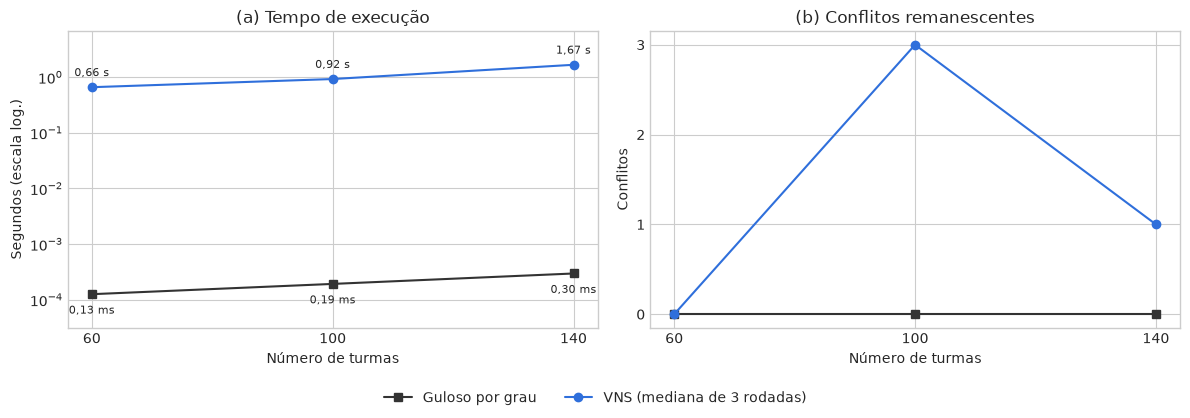

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax_t, ax_c) = plt.subplots(1, 2, figsize=(12, 4.2))
x = resumo['turmas']
series = [('Guloso por grau', resumo['guloso_tempo_s'], resumo['guloso_conflitos'], '#333333', 's'),
          ('VNS (mediana de 3 rodadas)', resumo['vns_tempo_mediana_s'], resumo['vns_conflitos_mediana'], '#2f6fdb', 'o')]
for nome, tempo, conflitos, cor, marca in series:
    ax_t.plot(x, tempo, marker=marca, color=cor, label=nome)
    ax_c.plot(x, conflitos, marker=marca, color=cor, label=nome)
for xi, t in zip(x, resumo['guloso_tempo_s']):
    ax_t.annotate(f'{t * 1e3:.2f} ms'.replace('.', ','), (xi, t), textcoords='offset points', xytext=(0, -14), ha='center', fontsize=8)
for xi, t in zip(x, resumo['vns_tempo_mediana_s']):
    ax_t.annotate(f'{t:.2f} s'.replace('.', ','), (xi, t), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
ax_t.set(yscale='log', title='(a) Tempo de execução', xlabel='Número de turmas', ylabel='Segundos (escala log.)', xticks=list(x))
ax_t.set_ylim(resumo['guloso_tempo_s'].min() / 4, resumo['vns_tempo_mediana_s'].max() * 4)
ax_c.set(title='(b) Conflitos remanescentes', xlabel='Número de turmas', ylabel='Conflitos', xticks=list(x))
ax_c.yaxis.get_major_locator().set_params(integer=True)
handles, labels = ax_t.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, frameon=False)
fig.tight_layout(rect=(0, 0.08, 1, 1))
fig.savefig(f'{PASTA}/figura_benchmark.png', dpi=200)
plt.show()

## 10. Ambiente de execução (seção 4.4)

In [ ]:
def comando(cmd):
    try:
        return subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=10).stdout.strip()
    except Exception:
        return ''

ambiente = {
    'inicio_execucao': INICIO_EXECUCAO,
    'fim_execucao': datetime.now().isoformat(timespec='seconds'),
    'sistema': platform.platform(),
    'python': platform.python_version(),
    'numpy': np.__version__, 'pandas': pd.__version__, 'matplotlib': matplotlib.__version__,
    'processador': comando("lscpu | sed -n 's/^Model name: *//p'") or platform.processor(),
    'cpus_logicas': os.cpu_count(),
    'memoria': comando("free -h | awk '/^Mem:/{print $2}'"),
    'distribuicao': comando("sed -n 's/^PRETTY_NAME=//p' /etc/os-release").strip('"'),
}
with open(f'{PASTA}/ambiente.json', 'w', encoding='utf-8') as f:
    json.dump(ambiente, f, ensure_ascii=False, indent=2)
ambiente

{'inicio_execucao': '2026-10-08T20:38:03',
 'fim_execucao': '2026-10-08T20:41:04',
 'sistema': 'Linux-5.15.167.4-microsoft-standard-WSL2-x86_64-with-glibc2.39',
 'python': '3.12.13',
 'numpy': '2.5.3',
 'pandas': '3.0.6',
 'matplotlib': '3.11.2',
 'processador': 'AMD Ryzen 5 5600G with Radeon Graphics',
 'cpus_logicas': 12,
 'memoria': '7.7Gi',
 'distribuicao': 'Ubuntu 24.04.5 LTS'}

## Observações

- O guloso atinge o limite inferior dado pelo maior grupo de alunos (`limite_inferior` em `instancias.csv`) quando seus horários coincidem com esse valor; nesse caso, ele é ótimo em número de horários.
- Possíveis extensões: partir a VNS da solução gulosa, outras vizinhanças (troca entre duas turmas, cadeias de Kempe), movimentos que esvaziem uma cor e restrições de salas, capacidade e preferências.